# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
| Rayhan Lutfi Hakim             |5054251043       |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
from sklearn.metrics import confusion_matrix
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix



In [2]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

df = pd.read_csv('D:\ML\Praktikum KNN\WineQT.csv')
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
C:\Users\M S I\AppData\Local\Temp\ipykernel_2068\1871548071.py:3: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('D:\ML\Praktikum KNN\WineQT.csv')


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


<Axes: >

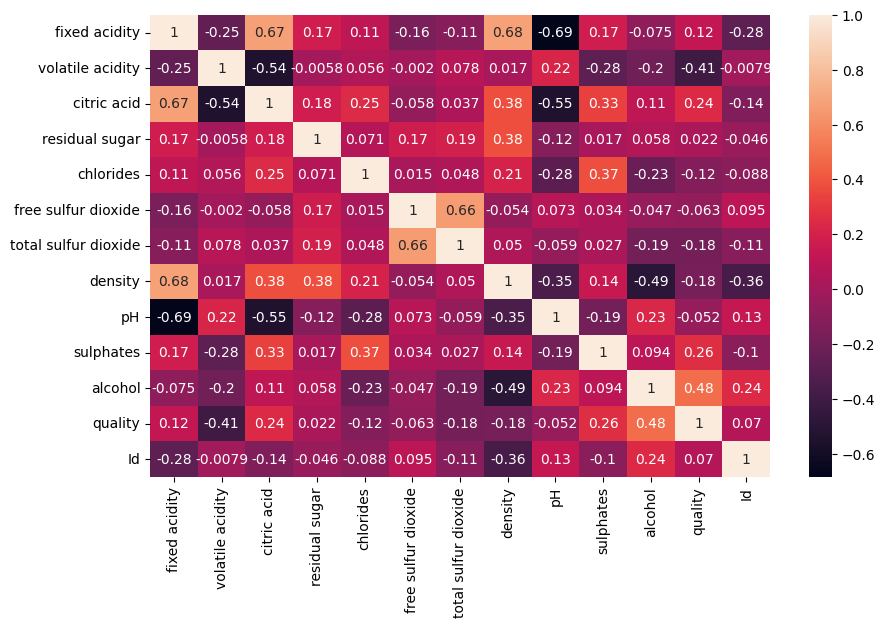

In [3]:
# Tampilkan Korelasi Matrix
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)

Tabel Frekuensi Tiap Kelas Quality:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


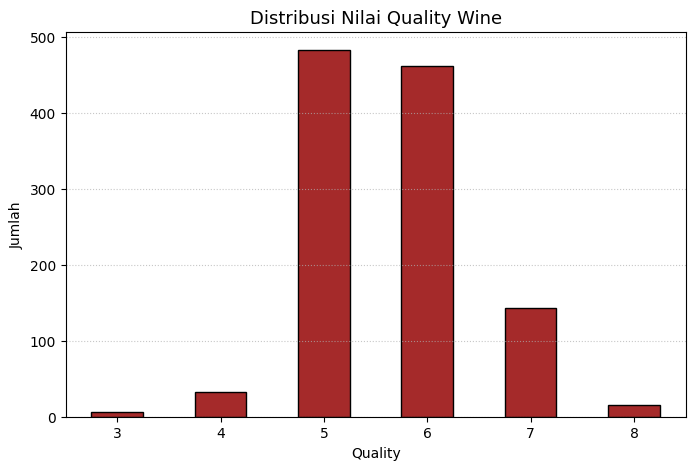

In [4]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.

print("Tabel Frekuensi Tiap Kelas Quality:")
print(df['quality'].value_counts().sort_index())

# Plot Bar Chart menggunakan pandas
plt.figure(figsize=(8, 5))
df['quality'].value_counts().sort_index().plot(
    kind='bar', color='darkwine' if 'darkwine' in plt.colormaps else 'brown', edgecolor='black'
)

plt.title('Distribusi Nilai Quality Wine', fontsize=13)
plt.xlabel('Quality')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()



## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

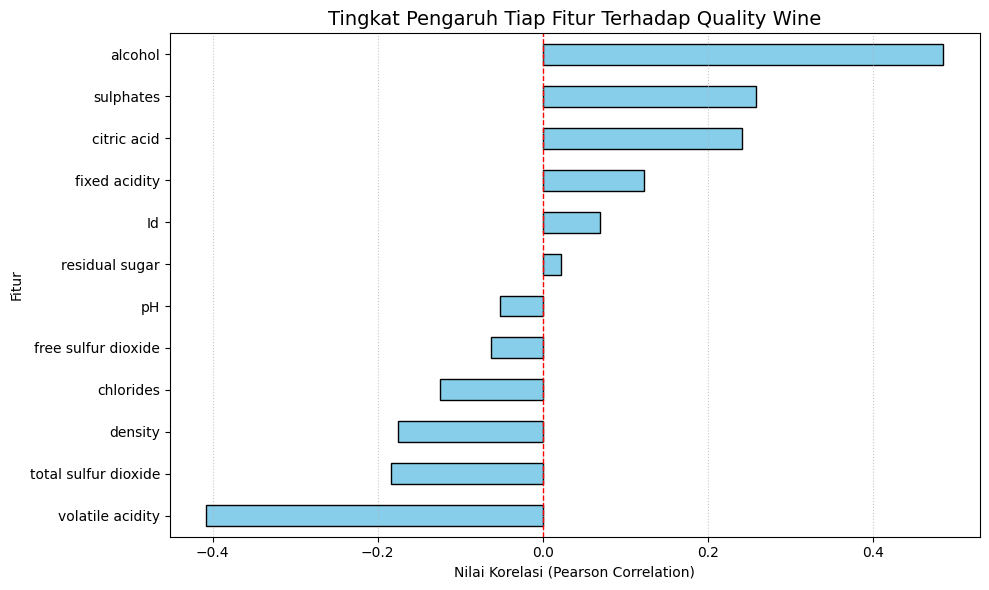

In [7]:
plt.figure(figsize=(10, 6))

# Hitung korelasi, buang kolom 'quality' itu sendiri agar tidak membandingkan dengan diri sendiri
quality_corr_bar = df.corr()['quality'].drop('quality').sort_values()

# Plot bar chart horizontal
quality_corr_bar.plot(kind='barh', color='skyblue', edgecolor='black')
plt.axvline(
    x=0, color='red', linestyle='--', linewidth=1
)  # Garis netral di angka 0
plt.title('Tingkat Pengaruh Tiap Fitur Terhadap Quality Wine', fontsize=14)
plt.xlabel('Nilai Korelasi (Pearson Correlation)')
plt.ylabel('Fitur')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Sulphate effect on quality of wine')

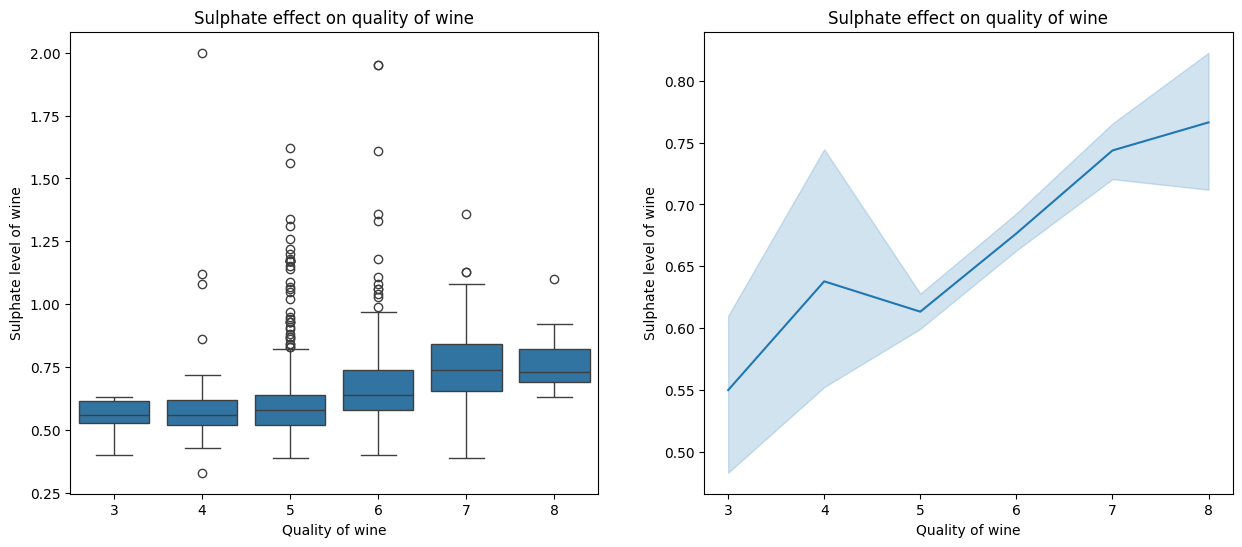

In [8]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,6))
sns.set_style()
sns.boxplot(x= "quality", y= "sulphates", data=df, ax= ax1)
ax1.set_xlabel("Quality of wine")
ax1.set_ylabel("Sulphate level of wine")
ax1.set_title("Sulphate effect on quality of wine")

sns.set_style()
sns.lineplot(x= "quality", y= "sulphates", data=df, ax= ax2)
ax2.set_xlabel("Quality of wine")
ax2.set_ylabel("Sulphate level of wine")
ax2.set_title("Sulphate effect on quality of wine")

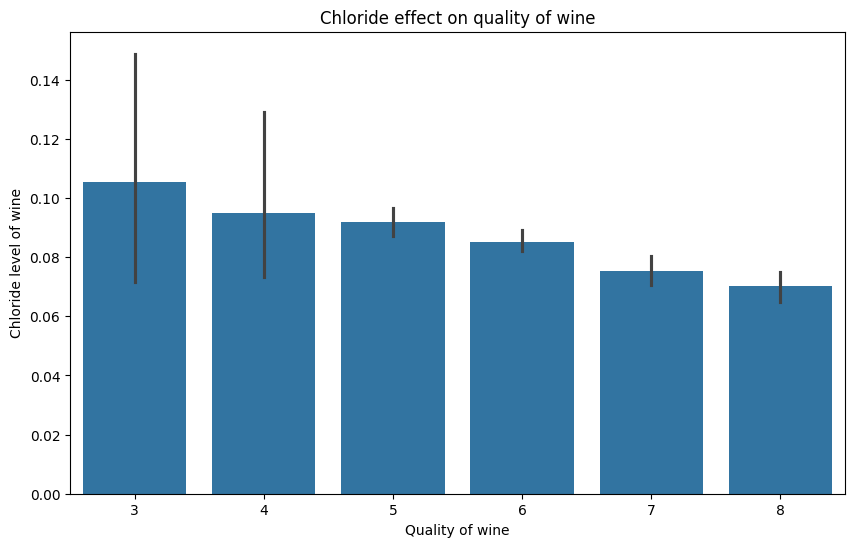

In [9]:
plt.figure(figsize=(10,6))
sns.set_style()
sns.barplot(x= "quality", y= "chlorides", data=df)
plt.xlabel("Quality of wine")
plt.ylabel("Chloride level of wine")
plt.title("Chloride effect on quality of wine")
plt.show()

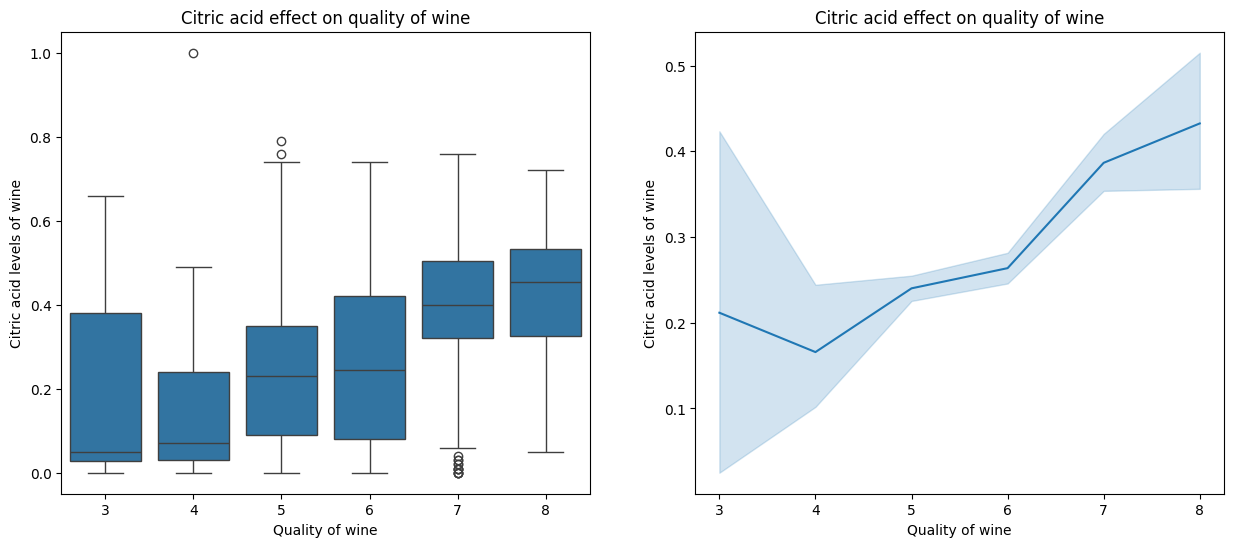

In [10]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,6))
sns.set_style()
sns.boxplot(x= "quality", y= "citric acid", data=df, ax= ax1)
ax1.set_xlabel("Quality of wine")
ax1.set_ylabel("Citric acid levels of wine")
ax1.set_title("Citric acid effect on quality of wine")

sns.set_style()
sns.lineplot(x= "quality", y= "citric acid", data=df, ax= ax2)
ax2.set_xlabel("Quality of wine")
ax2.set_ylabel("Citric acid levels of wine")
ax2.set_title("Citric acid effect on quality of wine")

plt.show()

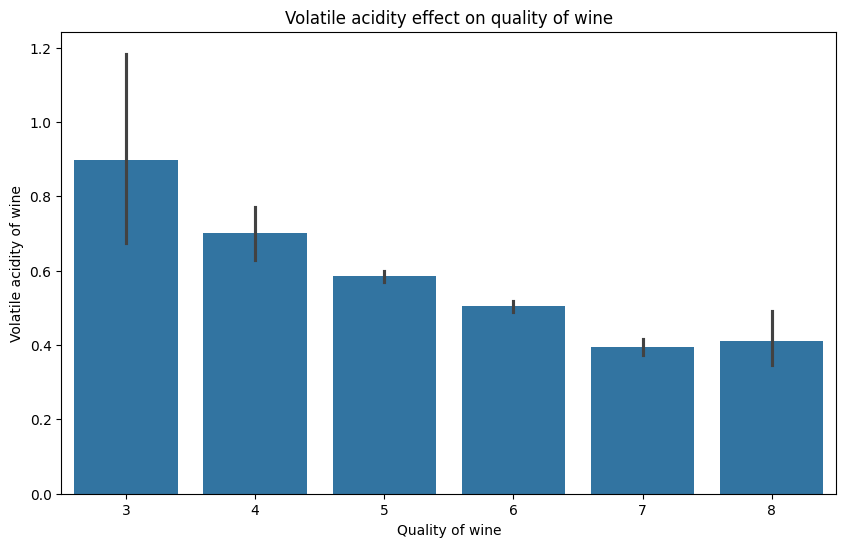

In [11]:
plt.figure(figsize=(10,6))
sns.set_style()
sns.barplot(x= "quality", y= "volatile acidity", data=df)
plt.xlabel("Quality of wine")
plt.ylabel("Volatile acidity of wine")
plt.title("Volatile acidity effect on quality of wine")
plt.show()

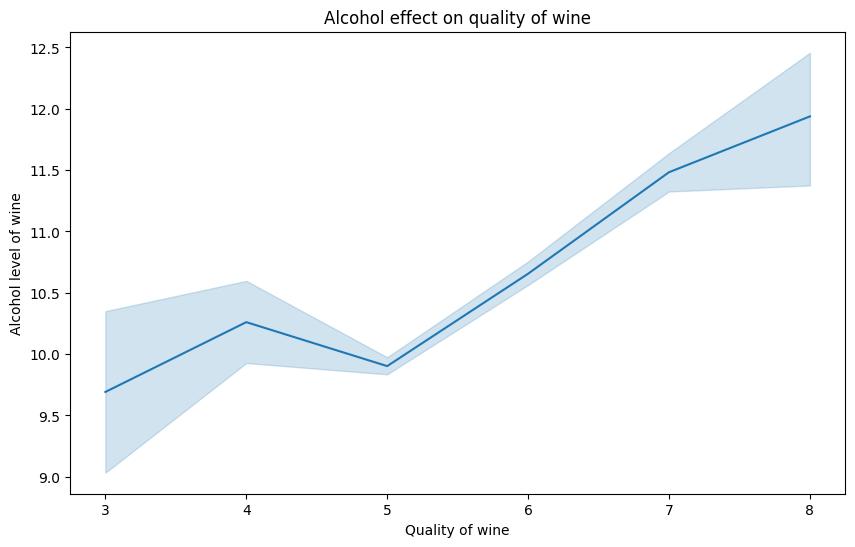

In [12]:
# Untuk menampilkan korelasi sebuah variabel
plt.figure(figsize=(10,6))
sns.set_style()
sns.lineplot(x= "quality", y= "alcohol", data=df)
plt.xlabel("Quality of wine")
plt.ylabel("Alcohol level of wine")
plt.title("Alcohol effect on quality of wine")
plt.show()


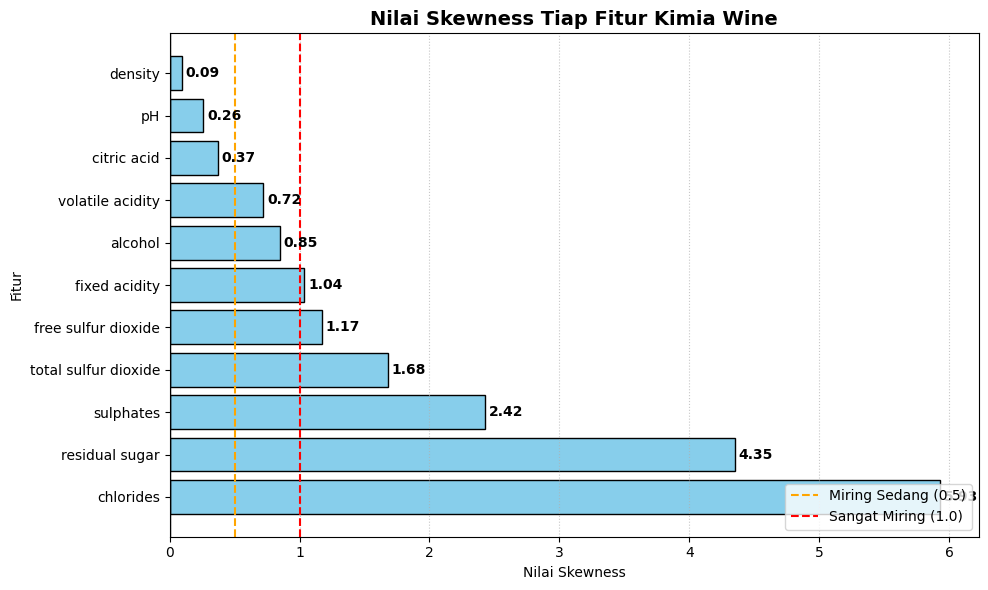

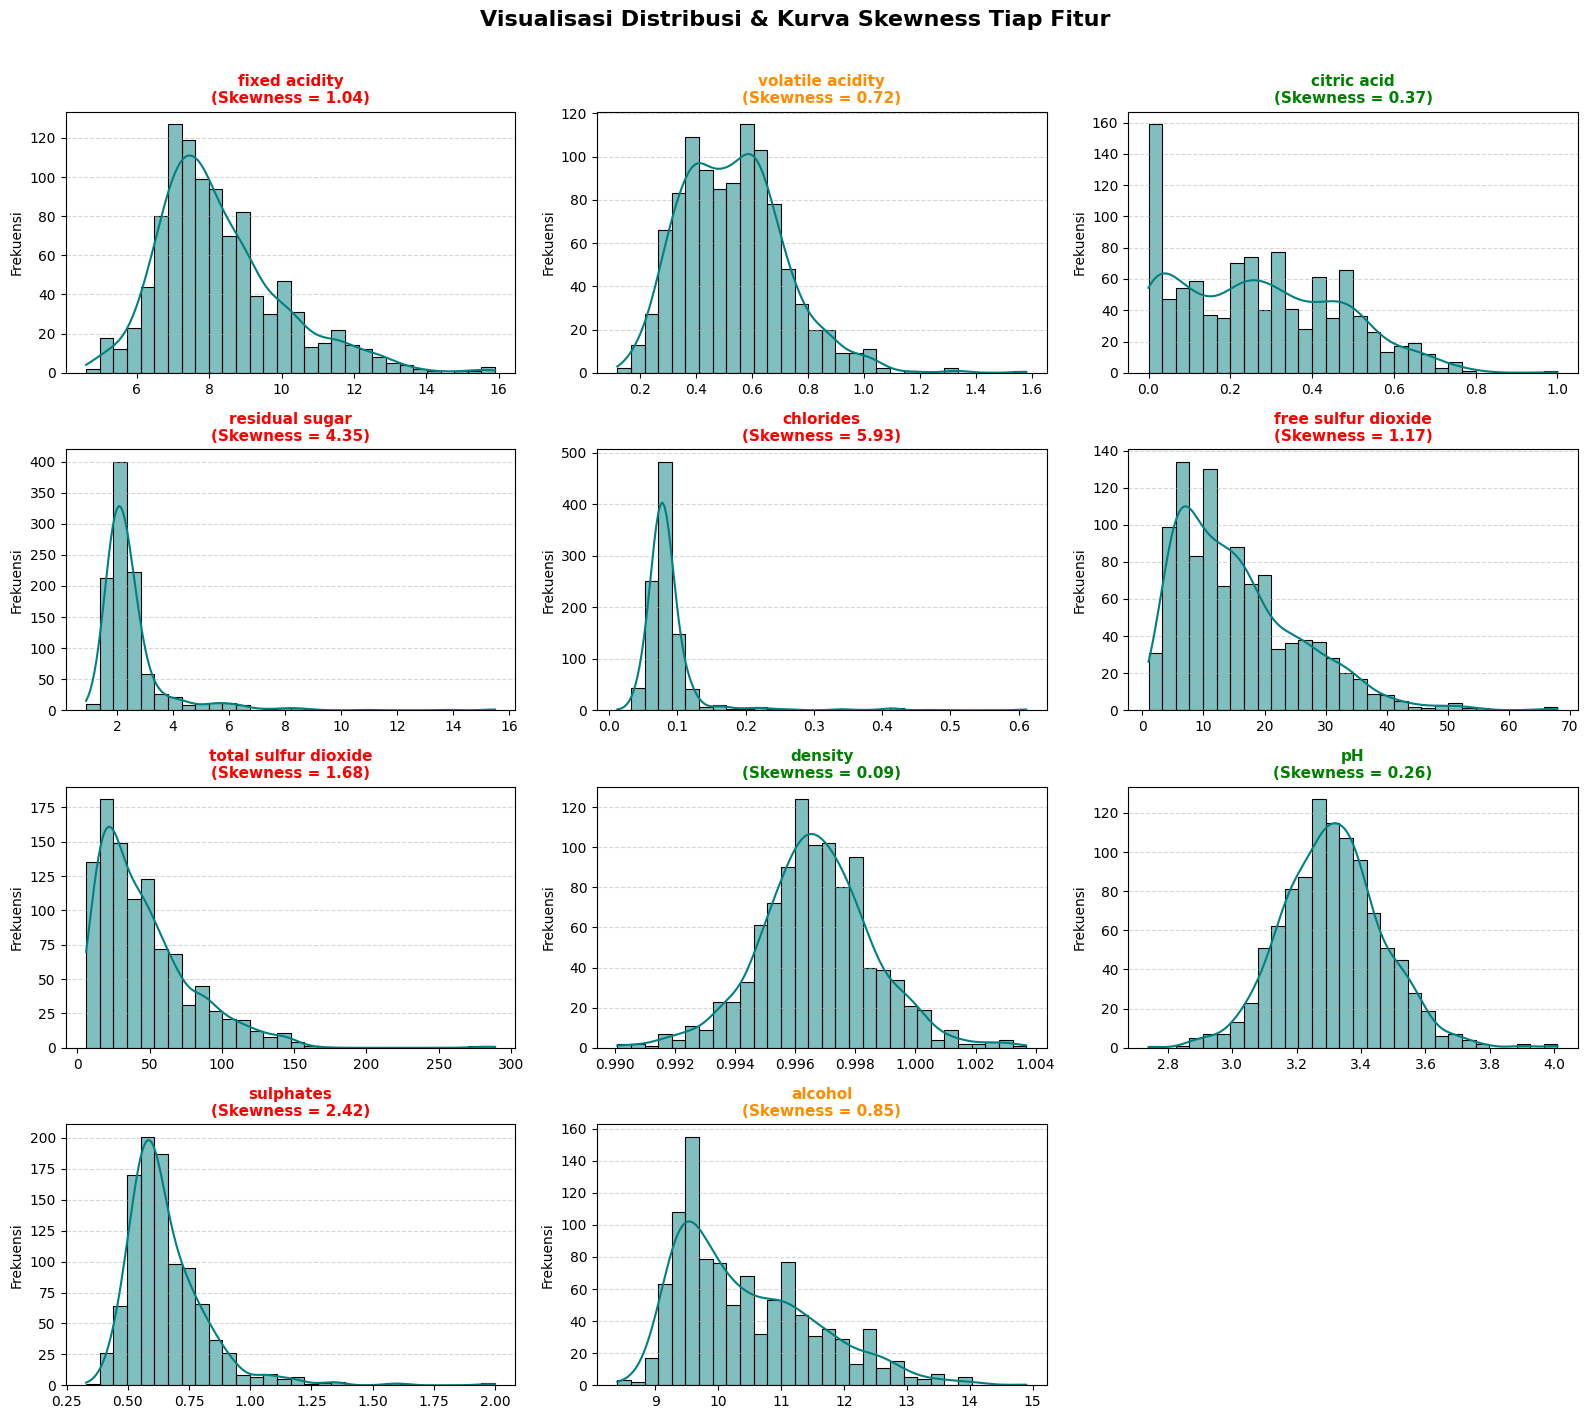

In [21]:
features = [col for col in df.columns if col not in ['quality', 'Id']]
skew_values = df[features].skew().sort_values(ascending=False)

# ─── 1. BARPLOT NILAI SKEWNESS FITUR ───
plt.figure(figsize=(10, 6))
bars = plt.barh(skew_values.index, skew_values.values, color='skyblue', edgecolor='black')

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.axvline(x=0.5, color='orange', linestyle='--', linewidth=1.5, label='Miring Sedang (0.5)')
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Sangat Miring (1.0)')

# Tampilkan nilai persis angka skewness di samping batang
for bar in bars:
    width = bar.get_width()
    offset = 0.03 if width >= 0 else -0.25
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}', va='center', fontsize=10, fontweight='bold')

plt.title('Nilai Skewness Tiap Fitur Kimia Wine', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Skewness')
plt.ylabel('Fitur')
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# ─── 2. GRAFIK DISTRIBUSI (HISTOGRAM + KURVA KDE) SETIAP FITUR ───
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    skew_val = df[col].skew()
    
    # Plot histogram dan kurva KDE
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', edgecolor='black', bins=30)
    
    # Judul berwarna: Merah (Sangat Miring >1.0), Oranye (Miring >0.5), Hijau (Normal)
    title_color = 'red' if abs(skew_val) > 1.0 else ('darkorange' if abs(skew_val) > 0.5 else 'green')
    axes[i].set_title(f'{col}\n(Skewness = {skew_val:.2f})', fontsize=11, fontweight='bold', color=title_color)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Sembunyikan subplot kosong sisa
for i in range(len(features), len(axes)):
    axes[i].axis('off')

plt.suptitle('Visualisasi Distribusi & Kurva Skewness Tiap Fitur', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# 2. Preprocessing




In [14]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
df = df.drop(columns=['Id'])
df = df.drop_duplicates()

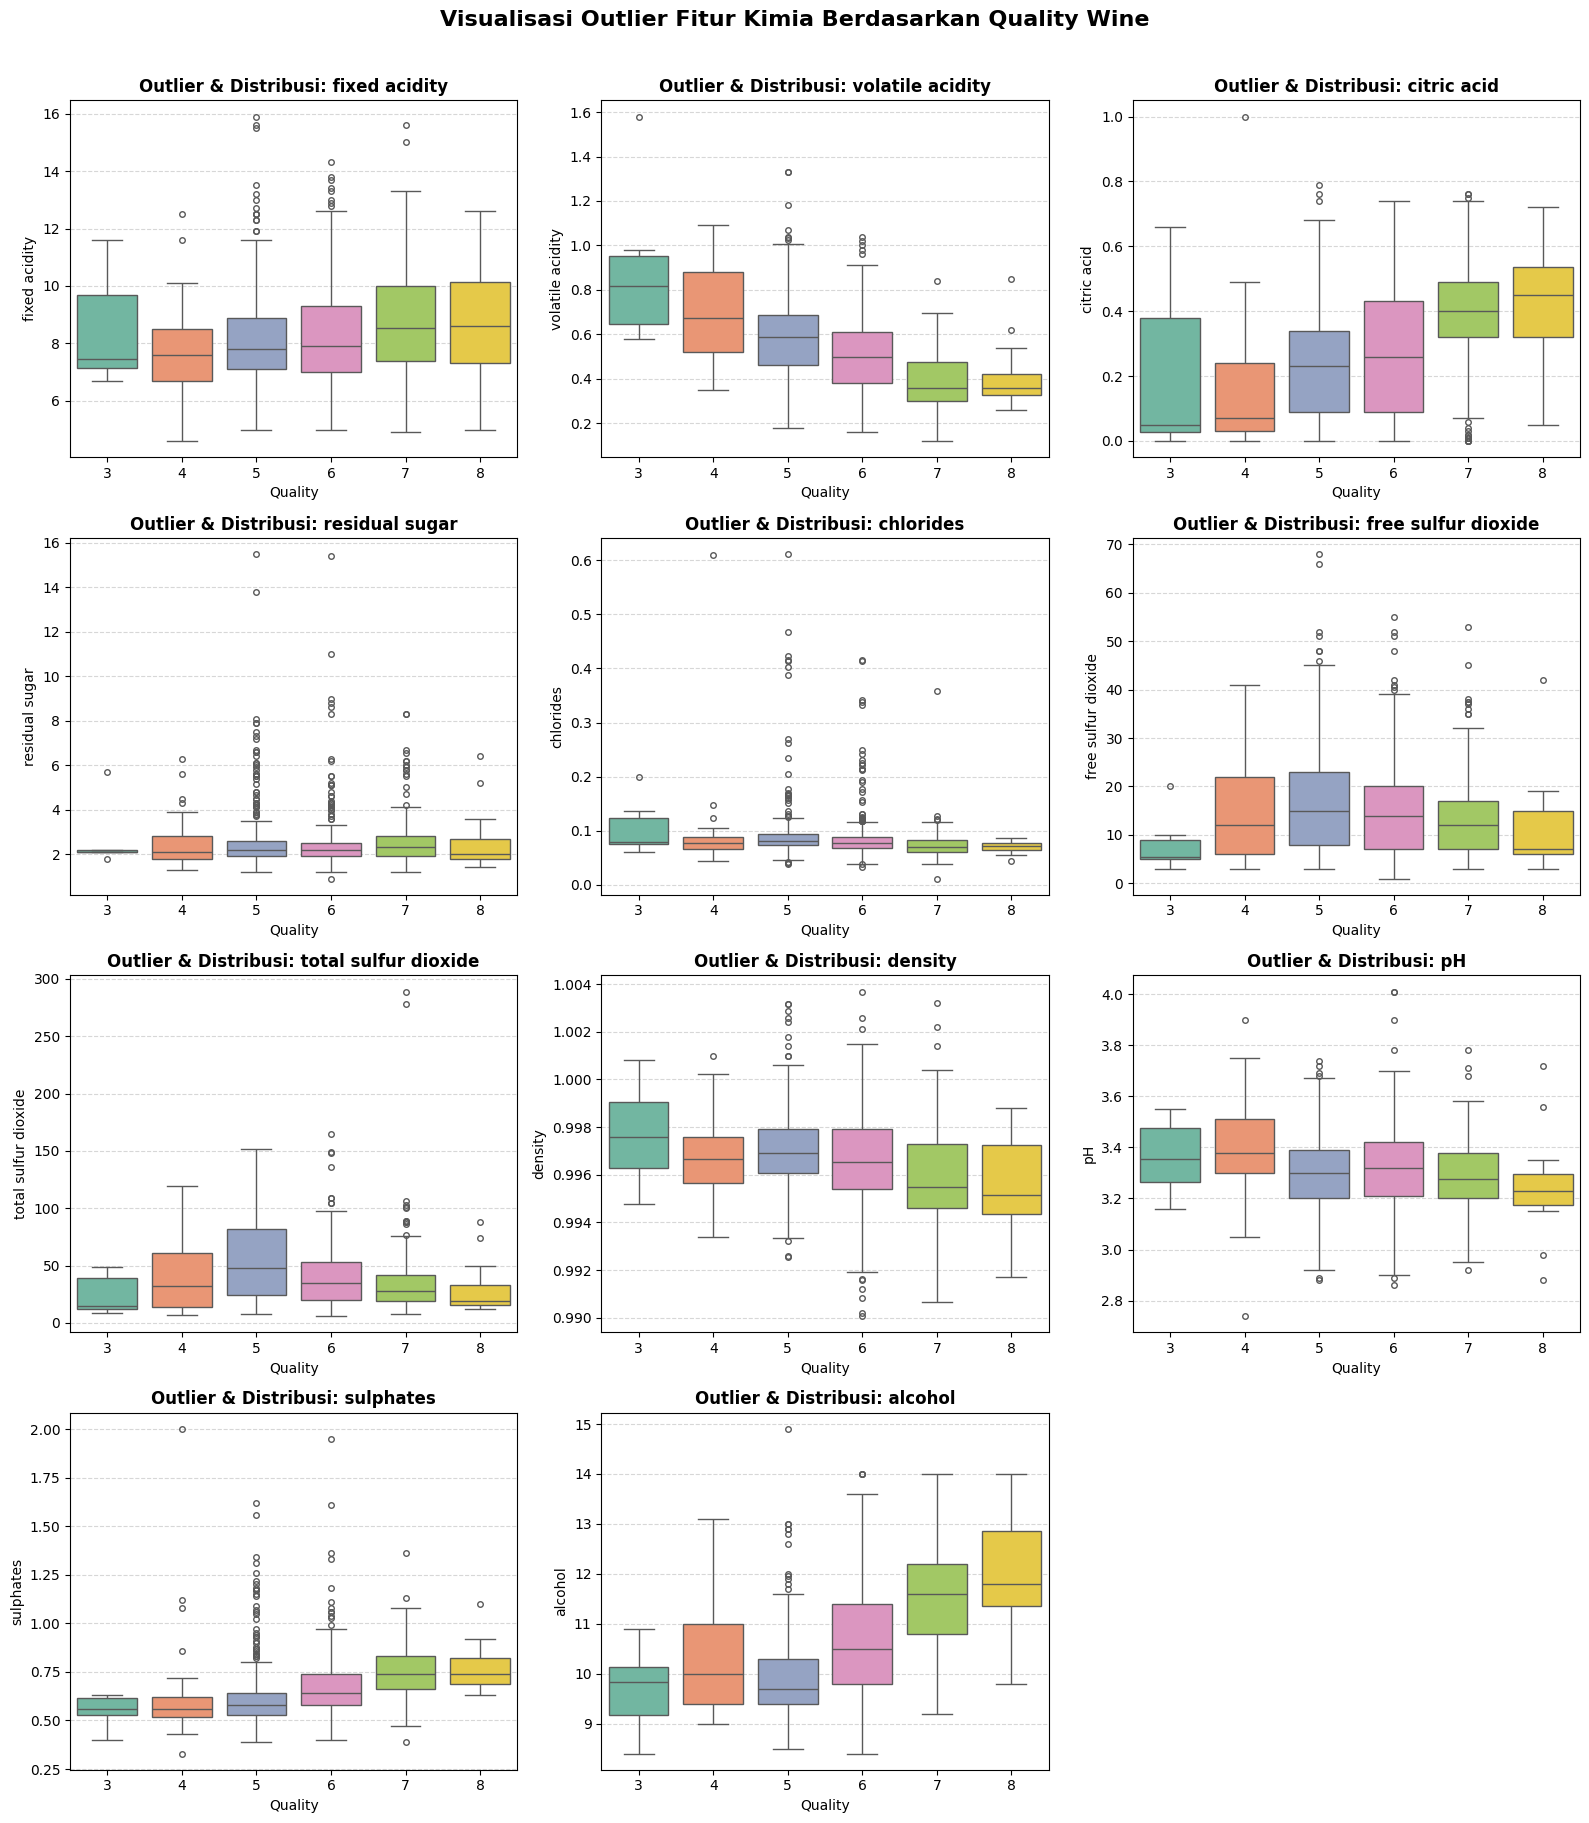

In [15]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
features = [col for col in df.columns if col not in ['Id', 'quality']]
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(
        data=df,
        x='quality',
        y=col,
        ax=axes[i],
        palette='Set2',
        hue='quality',
        legend=False,
        fliersize=4,  
    )
    axes[i].set_title(f'Outlier & Distribusi: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Quality', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
for i in range(len(features), len(axes)):
    axes[i].axis('off')
plt.suptitle(
    'Visualisasi Outlier Fitur Kimia Berdasarkan Quality Wine',
    fontsize=16,
    fontweight='bold',
    y=1.01,
)
plt.tight_layout()
plt.show()

In [16]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

X = df.drop(columns=['quality', 'Id'], errors='ignore')
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler_std = StandardScaler()
X_train_std_np = scaler_std.fit_transform(X_train)
X_test_std_np = scaler_std.transform(X_test)
X_train_std_df = pd.DataFrame(
    X_train_std_np, columns=X.columns, index=X_train.index
)
scaler_minmax = MinMaxScaler()
X_train_minmax_np = scaler_minmax.fit_transform(X_train)
X_test_minmax_np = scaler_minmax.transform(X_test)
X_train_minmax_df = pd.DataFrame(
    X_train_minmax_np, columns=X.columns, index=X_train.index
)

print("--- 1. Data Asli (Sebelum Scaling) ---")
display(X_train.head())

print("\n--- 2. Hasil StandardScaler (Mean ~0, Std ~1) ---")
display(X_train_std_df.head())

print("\n--- 3. Hasil MinMaxScaler (Skala 0 sampai 1) ---")
display(X_train_minmax_df.head())



--- 1. Data Asli (Sebelum Scaling) ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
584,12.9,0.50,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
127,8.8,0.61,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5
465,9.7,0.55,0.17,2.9,0.087,20.0,53.0,1.00040,3.14,0.61,9.4
963,6.1,0.34,0.25,1.8,0.084,4.0,28.0,0.99464,3.36,0.44,10.1
811,8.2,0.20,0.43,2.5,0.076,31.0,51.0,0.99672,3.53,0.81,10.4



--- 2. Hasil StandardScaler (Mean ~0, Std ~1) ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
584,2.677732,-0.140160,1.425271,0.196297,-0.320017,-0.856273,-0.688605,1.764346,-1.409565,0.123614,0.434105
127,0.287483,0.475938,-0.680115,-0.102089,-0.423807,-0.557939,-0.143171,0.077794,-0.768997,-0.402590,-0.852350
465,0.812172,0.139885,-0.526063,0.270893,-0.008645,0.436505,0.190150,1.911003,-1.089281,-0.285656,-0.944240
963,-1.286583,-1.036303,-0.115256,-0.549667,-0.070919,-1.154606,-0.567397,-1.105935,0.319969,-1.279598,-0.301012
811,-0.062309,-1.820428,0.809060,-0.027493,-0.236984,1.530394,0.129546,-0.016485,1.408936,0.883688,-0.025343



--- 3. Hasil MinMaxScaler (Skala 0 sampai 1) ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
584,0.734513,0.260274,0.55,0.130137,0.100167,0.089552,0.060284,0.737885,0.275591,0.209581,0.384615
127,0.371681,0.335616,0.14,0.102740,0.091820,0.134328,0.124113,0.501468,0.354331,0.155689,0.169231
465,0.451327,0.294521,0.17,0.136986,0.125209,0.283582,0.163121,0.758443,0.314961,0.167665,0.153846
963,0.132743,0.150685,0.25,0.061644,0.120200,0.044776,0.074468,0.335536,0.488189,0.065868,0.261538
811,0.318584,0.054795,0.43,0.109589,0.106845,0.447761,0.156028,0.488253,0.622047,0.287425,0.307692


# 3. Eksperimen Model KNN


In [17]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.
X = df.drop(columns=['quality'])
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaling_options = {
    'StandardScaler' : (X_train_std_np,   X_test_std_np),
    'MinMaxScaler'   : (X_train_minmax_np, X_test_minmax_np),
    'Tanpa Scaling'  : (X_train.values,    X_test.values),
}

k_values     = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37]
metrics      = ['euclidean', 'manhattan', "minkowski"]
results_list = []

for scaling_name, (X_tr, X_te) in scaling_options.items():
    for metric in metrics:
        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')
            knn.fit(X_tr, y_train)
            train_acc = accuracy_score(y_train, knn.predict(X_tr))
            test_acc  = accuracy_score(y_test,  knn.predict(X_te))
            results_list.append({
                'Scaling'       : scaling_name,
                'Metrik Jarak'  : metric.capitalize(),
                'Nilai k'       : k,
                'Train Accuracy': round(train_acc, 4),
                'Test Accuracy' : round(test_acc,  4),
            })
df_results = pd.DataFrame(results_list)
display(df_results.sort_values('Test Accuracy', ascending=False).head(10))
best_row    = df_results.loc[df_results['Test Accuracy'].idxmax()]
best_k      = int(best_row['Nilai k'])
best_metric = best_row['Metrik Jarak'].lower()
best_scaler_name = best_row['Scaling']
print(f"\nModel Terbaik → Scaling={best_scaler_name}, k={best_k}, Metrik={best_metric.capitalize()}")
print(f"Test Accuracy Terbaik → {best_row['Test Accuracy'] * 100:.2f}%")
best_X_tr, best_X_te = scaling_options[best_scaler_name]
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, weights='distance')
best_knn.fit(best_X_tr, y_train)
y_pred = best_knn.predict(best_X_te)


,Scaling,Metrik Jarak,Nilai k,Train Accuracy,Test Accuracy
9,StandardScaler,Euclidean,19,1.0,0.6127
47,StandardScaler,Minkowski,19,1.0,0.6127
14,StandardScaler,Euclidean,29,1.0,0.6078
50,StandardScaler,Minkowski,25,1.0,0.6078
52,StandardScaler,Minkowski,29,1.0,0.6078
12,StandardScaler,Euclidean,25,1.0,0.6078
13,StandardScaler,Euclidean,27,1.0,0.6029
51,StandardScaler,Minkowski,27,1.0,0.6029
15,StandardScaler,Euclidean,31,1.0,0.5980
34,StandardScaler,Manhattan,31,1.0,0.5980



Model Terbaik → Scaling=StandardScaler, k=19, Metrik=Euclidean
Test Accuracy Terbaik → 61.27%


# 4. Evaluasi Model


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.69      0.70      0.69        87
           6       0.57      0.65      0.61        82
           7       0.52      0.46      0.49        24
           8       0.00      0.00      0.00         3

    accuracy                           0.61       204
   macro avg       0.30      0.30      0.30       204
weighted avg       0.58      0.61      0.60       204



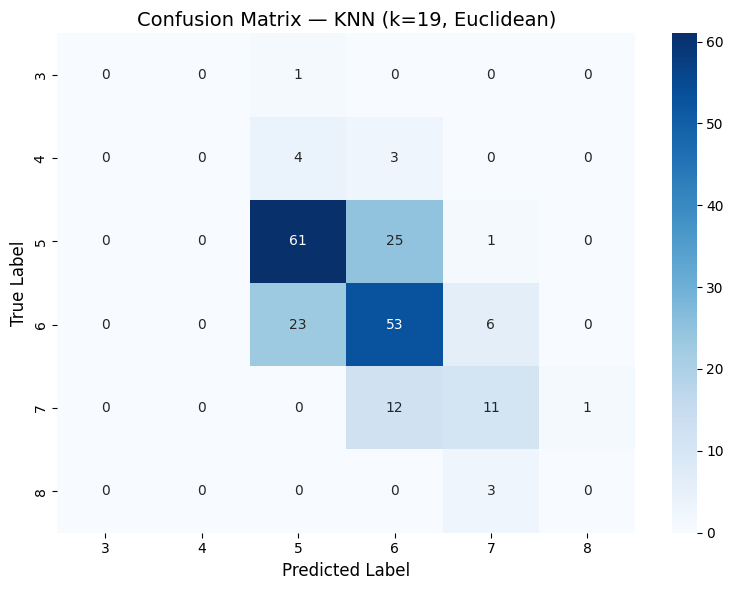

In [18]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title(f'Confusion Matrix — KNN (k={best_k}, {best_metric.capitalize()})', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

Dari hasil beberapa eksperimen seperti mengubah nilai K dan metriks yang digunakan, untuk K terbaik ada di 19 dan metriks euclidean selalu menghasilkan hasil yang lebih bagus karena dengan 2 faktor tersebut bisa menghasilkan akurasi yang tinggi. Untuk Scaler sendiri lebih baik standard scaler dibandingkan dengan minmax scaler karena terdapat outlier berlebihan pada fitur sulphates, chlorides, total sulfur dioxide yang membuat nilai max pada rumus scaler minmax ditarik terlalu jauh. Terlihat juga jika tanpa scaler hasil tidak akan menjadi terbaik karena adanya tumpang tindih antar kandungan dalam wine. Sebagai contoh total sulfur dioxide yang memiliki skala sangat tinggi yaitu 289, sehingga perlu adanya scaling data untuk menyeimbangkan kontribusi tiap fitur. Perbedaan antara weight distance dan uniform juga berpengaruh di mana untuk kasus ini distance lebih baik dengan menghasilkan presentase 61.27% dibanding uniform yang hanya 59.80%

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Kesimpulannya adalah masih banyak sekali hal hal yang bisa diperbaiki mulai dari Preprocessing seperti menyeimbangkan data yang masih inbalance seperti kualitas wine yang terlalu dominan di 5 dan 6 sehingga 3,4,8 tidak terpakai sama sekali. Saran lainnya adalah mengubah model selain KNN yang lebih baik seperti Random Forest atau XGBoost karena tidak memedulikan outlier dan tidak memerlukan scalling data. Selain itu XGBoost dan Random Forest lebih baik karena menggunakan metode ensemble (gabungan banyak pohon keputusan) yang mampu menangani data kompleks, berdimensi tinggi, dan kebal terhadap overfitting serta skala fitur yang berbeda. Lakukan Log Transform pada chlorides, residual sugar, sulphates, total sulfur dioxide.